## ================================
# INSTRUCTIONS TO RUN THIS PROJECT
# ================================
# 1. Upload all dataset CSV files (provided in submission) into Google Colab.
#    - Click the folder icon (left sidebar)
#    - Click "Upload"
#    - Select all dataset files
#
# 2. Ensure all files are in the same directory as this notebook.
#
# 3. Run all cells from top to bottom.
#
# NOTE:
# Due to file size constraints, datasets are not included in the GitHub repository.
# All datasets are provided in the submission files.

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc)
import re
import warnings
import time
warnings.filterwarnings('ignore')

In [ ]:
#import and download NLTK resources
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('punkt_tab')#used punkt and punkt_tab due to the latest versions of nltk no longer using punkt
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from nltk.metrics import agreement
#loads dataset
fake_df = pd.read_csv('Fake.csv', encoding='latin-1')
real_df = pd.read_csv('True.csv', encoding='latin-1')
politifact_fake_df = pd.read_csv('politifact_fake.csv', encoding='latin-1')
politifact_real_df = pd.read_csv('politifact_real.csv',encoding='latin-1')
fake_newsnet_df = pd.read_csv('FakeNewsNet.csv', encoding='latin-1')
welFake_df = pd.read_csv('WELFake_Dataset.csv', encoding='latin-1')
ag_news_df = pd.read_csv('AGreal.csv', encoding='latin-1')
covid_fake_df = pd.read_csv('NewsFakeCOVID-19.csv')
covid_real_df = pd.read_csv('NewsRealCOVID-19.csv')

In [ ]:
ag_news_df = ag_news_df.sample(n=2500, random_state=42)  #the dataset is far too big, slows down process

In [ ]:
#Add labels
fake_df['label'] = 0
real_df['label'] = 1
politifact_fake_df['label'] = 0
politifact_real_df['label'] = 1
fake_newsnet_df['label'] = 0
ag_news_df['label'] = 1
covid_fake_df['label'] = 0
covid_real_df['label'] = 1

#Combine title and text
fake_df['content'] = fake_df['title'].fillna('') + " " + fake_df['text'].fillna('')
real_df['content'] = real_df['title'].fillna('') + " " + real_df['text'].fillna('')
politifact_fake_df['content'] = politifact_fake_df['news']
politifact_real_df['content'] = politifact_real_df['news']
fake_newsnet_df['content'] = fake_newsnet_df['title']
welFake_df['content'] = welFake_df['title'].fillna('') + ' ' + welFake_df['text'].fillna('')
ag_news_df['content'] = ag_news_df['Title'].fillna('') + ' ' + ag_news_df['Description'].fillna('')
covid_fake_df['content'] = covid_fake_df['title'].fillna('') + ' ' + covid_fake_df['content'].fillna('')
covid_real_df['content'] = covid_real_df['title'].fillna('') + ' ' + covid_real_df['content'].fillna('')

In [ ]:
#Combine all the datasets + remove duplicates
df = pd.concat([
    fake_df[['content','label']],
    real_df[['content','label']],
    politifact_fake_df[['content','label']],
    politifact_real_df[['content','label']],
    fake_newsnet_df[['content','label']],
    ag_news_df[['content','label']],
    welFake_df[['content','label']],
    covid_fake_df[['content', 'label']],
    covid_real_df[['content', 'label']],
], ignore_index=True)
df = df.drop_duplicates(subset=['content']).reset_index(drop=True)
df = df.dropna()


In [ ]:
real = df[df['label'] == 1]
fake = df[df['label'] == 0]
df = pd.concat([real, fake]).sample(frac=1, random_state=42).reset_index(drop=True)
print(df['label'].value_counts())

label
0    57510
1    52658
Name: count, dtype: int64


In [ ]:
print(f"Total articles: {len(df)}")

fake_count = (df['label'] == 0).sum()
real_count = (df['label'] == 1).sum()

print(f"Fake news: {fake_count} ({fake_count/len(df)*100:.1f}%)")
print(f"Real news: {real_count} ({real_count/len(df)*100:.1f}%)")


Total articles: 110168
Fake news: 57510 (52.2%)
Real news: 52658 (47.8%)


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:
def preprocess_text(text):
#The pipeline is as follows: lowercase conversion,
#the removal of URLs, special characters and emails, undergoing tokenisation, the removal of stop words and lemmatisation
    if pd.isna(text) or text == '':
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  #Removes URLs
    text = re.sub(r'@\w+|#\w+', '', text)  #Removes mentions/hashtags
    text = re.sub(r'\S+@\S+', '', text)  #Removes emails
    text = re.sub(r'[^a-zA-Z\s]', '', text)  #Removes punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  #Removes extra whitespace

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)


In [ ]:
#Run a test to ensure the preprocessing worked
print("Preprocessing Example:")
sample_original = df['content'].iloc[0][:250]
sample_cleaned = preprocess_text(sample_original)

print("\nBEFORE:")
print(sample_original)
print("\nAFTER:")
print(sample_cleaned)

Preprocessing Example:

BEFORE:
 Trump In For TREMENDOUS Shock If He Thinks He Can Just Refuse To Accept Election Night Loss Trump has been very clear for the last week or so   he will not accept the results of Election Night if he s not the winner. He even said at a rally in Ohio:

AFTER:
trump tremendous shock think refuse accept election night loss trump clear last week accept result election night winner even said rally ohio


In [ ]:
#Apply preprocessing throughout all the articles
print("Preprocessing all articles")

df['cleaned_text'] = df['content'].apply(preprocess_text)


df = df[df['cleaned_text'].str.len() > 10].reset_index(drop=True)

print(f"Final dataset: {len(df)} articles")

Preprocessing all articles
Final dataset: 109920 articles


In [ ]:
X = df['cleaned_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)


In [ ]:
# TF-IDF Vectorization
#n-grams are used to learn phrases and local context, instead of treating words independently of one another.
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"   Feature matrix shape: {X_train_tfidf.shape}")
print(f"   Number of features: {X_train_tfidf.shape[1]}")

   Feature matrix shape: (87936, 5000)
   Number of features: 5000


In [ ]:
#Model training
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Naive Bayes': MultinomialNB(alpha=0.1),#MultinomialNB is used over gaussian as it's more suitable for text classification problems
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'SVM': LinearSVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
trained_models = {}

In [ ]:
for name, model in models.items():
    print(f"\nTraining {name}...", end=" ✔ ")

    model.fit(X_train_tfidf, y_train)

    trained_models[name] = model
    y_pred = model.predict(X_test_tfidf)

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'predictions': y_pred
    }

print("\nAll models trained successfully!")


Training Logistic Regression... ✔ 
Training Naive Bayes... ✔ 
Training KNN... ✔ 
Training SVM... ✔ 
Training Random Forest... ✔ 
All models trained successfully!


In [ ]:
comparison_df = pd.DataFrame(results).T[['accuracy', 'precision', 'recall', 'f1_score']]
comparison_df = comparison_df.round(2)

print("\n" + comparison_df.to_string(float_format="{:.2f}".format))

best_model_name = comparison_df['accuracy'].idxmax()
best_accuracy = comparison_df['accuracy'].max()

print(f"The best model is : {best_model_name} ({best_accuracy:.2%} accuracy)")


                    accuracy precision recall f1_score
Logistic Regression     0.89      0.89   0.88     0.89
Naive Bayes             0.81      0.81   0.80     0.80
KNN                     0.58      0.89   0.14     0.25
SVM                     0.89      0.89   0.89     0.89
Random Forest           0.90      0.89   0.90     0.90
The best model is : Random Forest (90.22% accuracy)


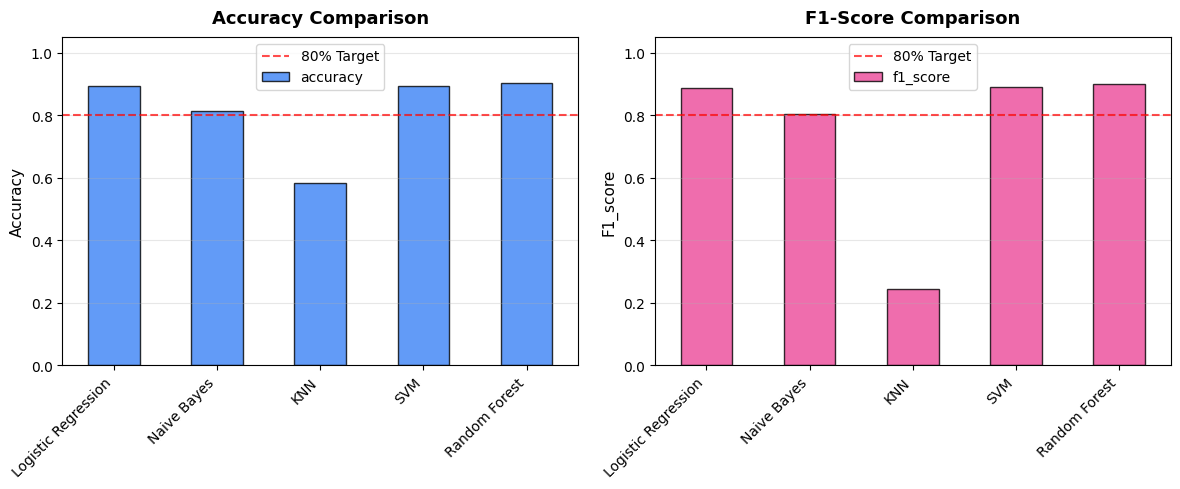

In [ ]:
#Visualize metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics = ['accuracy', 'f1_score']
titles = ['Accuracy Comparison', 'F1-Score Comparison']
colors = ['#3b82f6', '#ec4899']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx]
    comparison_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.8, edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.axhline(y=0.8, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Target')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

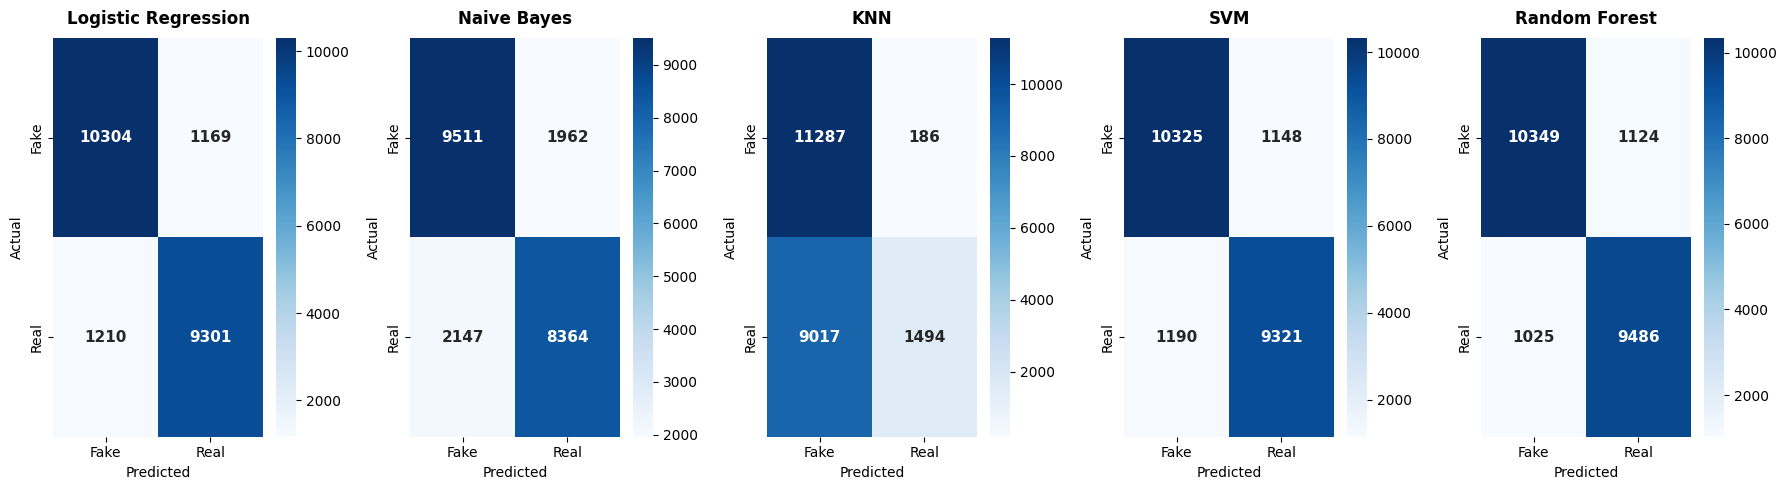

In [ ]:
#Confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])

    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                ax=axes[idx],
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'],
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})

    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

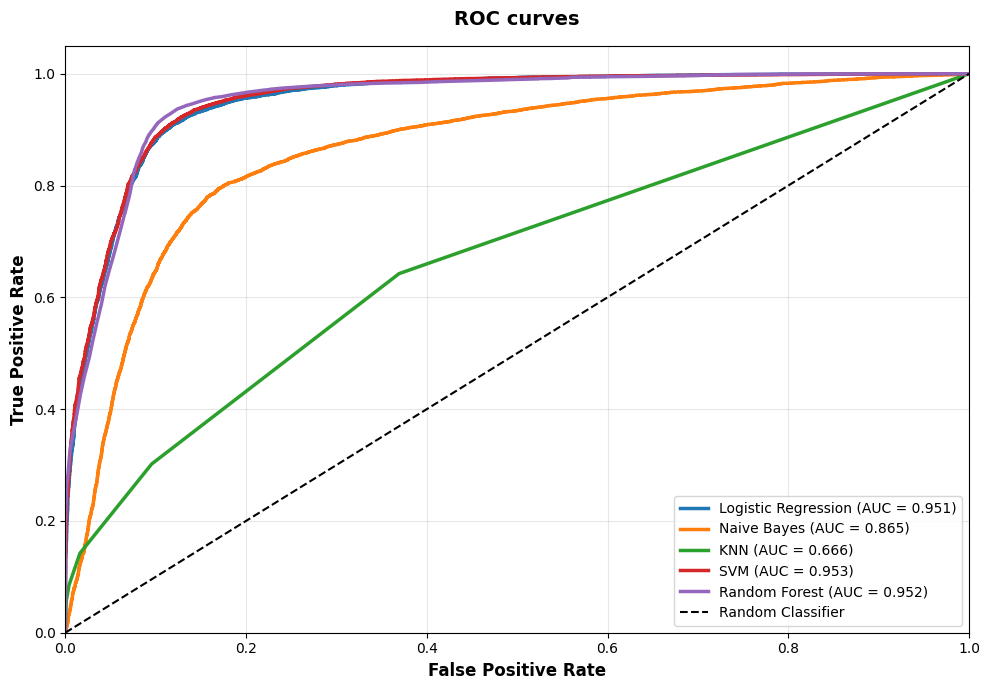

In [ ]:
#AUC-ROC curve
plt.figure(figsize=(10, 7))

for name, model in trained_models.items():

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_tfidf)[:, 1]

    elif hasattr(model, 'decision_function'):
        y_proba = model.decision_function(X_test_tfidf)

    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC curves', fontsize=14, fontweight='bold', pad=15)

plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



🌐Streamlit Web App Deployment




In [ ]:
!pip install streamlit pyngrok -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.7 MB/s eta 0:00:00


In [ ]:
import pickle

#Pick the best model
best_model_name = comparison_df['accuracy'].idxmax()
best_model      = trained_models[best_model_name]
best_metrics    = results[best_model_name]

payload = {
    'model':      best_model,
    'vectorizer': tfidf,
    'model_name': best_model_name,
    'metrics': {
        'accuracy':  round(best_metrics['accuracy'],  4),
        'precision': round(best_metrics['precision'], 4),
        'recall':    round(best_metrics['recall'],    4),
        'f1_score':  round(best_metrics['f1_score'],  4),
    },
    'all_results': {
        name: {
            'accuracy':  round(m['accuracy'],  4),
            'precision': round(m['precision'], 4),
            'recall':    round(m['recall'],    4),
            'f1_score':  round(m['f1_score'],  4),
        }
        for name, m in results.items()
    }
}

with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(payload, f)

print(f'Best model : {best_model_name}')
print(f'F1-Score   : {best_metrics["f1_score"]:.4f}')
print(f'Accuracy   : {best_metrics["accuracy"]:.4f}')
print('Model saved to fake_news_model.pkl')


Best model : Random Forest
F1-Score   : 0.8983
Accuracy   : 0.9022
Model saved to fake_news_model.pkl


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import re, pickle, os

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
MODEL_PATH  = 'fake_news_model.pkl'

#Pre-processing
def preprocess_text(text):
    if pd.isna(text) or text == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

@st.cache_resource(show_spinner=False)
def load_model():
    if os.path.exists(MODEL_PATH):
        with open(MODEL_PATH, 'rb') as f:
            return pickle.load(f)
    return None

def predict_article(text, payload):
    cleaned = preprocess_text(text)
    vec     = payload['vectorizer'].transform([cleaned])
    model   = payload['model']
    pred    = model.predict(vec)[0]
    if hasattr(model, 'predict_proba'):
        proba      = model.predict_proba(vec)[0]
        confidence = float(max(proba))
    elif hasattr(model, 'decision_function'):
        score      = model.decision_function(vec)[0]
        confidence = float(1 / (1 + np.exp(-abs(score))))
    else:
        confidence = 1.0
    return {'label': 'REAL' if pred == 1 else 'FAKE', 'confidence': confidence}


st.set_page_config(page_title='TruthLens', page_icon='🔍', layout='wide')

st.markdown('''
<style>
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@700;800&family=DM+Sans:wght@300;400;500&display=swap');
html,body,[class*="css"]{font-family:"DM Sans",sans-serif;background:#0c0c10;color:#e8e8f0}
section[data-testid="stSidebar"]{background:#111118;border-right:1px solid #222230}
.hero{text-align:center;padding:2rem 1rem 1.5rem}
.hero h1{font-family:"Syne",sans-serif;font-size:3rem;font-weight:800;
  background:linear-gradient(135deg,#60a5fa,#a78bfa,#f472b6);
  -webkit-background-clip:text;-webkit-text-fill-color:transparent;margin:0}
.hero p{color:#888;font-size:1rem;font-weight:300;margin-top:.4rem}
.card{background:#14141e;border:1px solid #222230;border-radius:14px;padding:1.6rem 1.8rem;margin-bottom:1.2rem}
.verdict-fake{background:linear-gradient(135deg,#3d0a0a,#1a0505);border:1.5px solid #ef4444;border-radius:14px;padding:1.8rem;text-align:center}
.verdict-real{background:linear-gradient(135deg,#052a1a,#031510);border:1.5px solid #10b981;border-radius:14px;padding:1.8rem;text-align:center}
.verdict-label{font-family:"Syne",sans-serif;font-size:2.5rem;font-weight:800;letter-spacing:2px}
.verdict-sub{font-size:.9rem;color:#aaa;margin-top:.3rem}
.conf-wrap{background:#1a1a26;border-radius:999px;height:10px;margin-top:.9rem;overflow:hidden}
.conf-bar-real{background:linear-gradient(90deg,#10b981,#34d399);height:100%;border-radius:999px}
.conf-bar-fake{background:linear-gradient(90deg,#ef4444,#f87171);height:100%;border-radius:999px}
.model-badge{display:inline-block;background:linear-gradient(135deg,#1e1b4b,#312e81);
  border:1px solid #6366f1;color:#c7d2fe;border-radius:999px;padding:.25rem 1rem;
  font-size:.82rem;font-weight:500}
div.stButton>button{background:linear-gradient(135deg,#6366f1,#a855f7);color:white;
  border:none;border-radius:10px;padding:.65rem 2.2rem;font-family:"Syne",sans-serif;
  font-weight:600;font-size:1rem;width:100%}
textarea{background:#14141e!important;border:1px solid #2a2a3a!important;
  color:#e8e8f0!important;border-radius:10px!important}
.cmp-table{width:100%;border-collapse:collapse}
.cmp-table th{font-size:.72rem;text-transform:uppercase;letter-spacing:.1em;color:#666;
  border-bottom:1px solid #222;padding:.5rem .8rem;text-align:right}
.cmp-table th:first-child{text-align:left}
.cmp-table td{padding:.55rem .8rem;font-size:.88rem;border-bottom:1px solid #1a1a26;
  text-align:right;color:#ccc}
.cmp-table td:first-child{text-align:left;color:#e8e8f0;font-weight:500}
.cmp-table tr.best-row td{color:#a78bfa;font-weight:600}
.cmp-table tr.best-row td:first-child::after{content:" ★";font-size:.7rem}
</style>
''', unsafe_allow_html=True)

payload = load_model()



#Hero
st.markdown(
    '<div class="hero"><h1>TruthLens</h1>'
    '<p>Real-time fake news detection</p></div>',
    unsafe_allow_html=True)

tab_detect, = st.tabs(['👁️ Detect'])

#Detect tab
with tab_detect:
    if payload is None:
        st.error('Model not loaded. Make sure fake_news_model.pkl exists in the same directory.')
    else:
        col_in, col_out = st.columns([1.1, 0.9], gap='large')
        with col_in:
            st.markdown('#### Paste article text')
            article = st.text_area('', placeholder='Paste a news headline or article body here…',
                                   height=260, label_visibility='hidden')
            st.caption(f'{len(article.split()) if article.strip() else 0} words')
            run = st.button('Analyse Article')

        with col_out:
            if run:
                if len(article.strip()) < 20:
                    st.error('Please paste at least a sentence of text.')
                else:
                    result  = predict_article(article, payload)
                    is_real = result['label'] == 'REAL'
                    icon    = '✅' if is_real else '🚨'
                    color   = '#10b981' if is_real else '#ef4444'
                    cls     = 'verdict-real' if is_real else 'verdict-fake'
                    bar_cls = 'conf-bar-real' if is_real else 'conf-bar-fake'
                    pct     = result['confidence'] * 100
                    st.markdown(f'''
                    <div class="{cls}">
                      <div class="verdict-label" style="color:{color}">{icon}&nbsp;{result['label']} NEWS</div>
                      <div class="verdict-sub">Confidence: {pct:.1f}%</div>
                      <div class="conf-wrap">
                        <div class="{bar_cls}" style="width:{pct:.1f}%"></div>
                      </div>
                    </div>
                    <br>
                    <div class="card" style="margin:0;text-align:center">
                      <div style="font-size:.75rem;color:#555;text-transform:uppercase;letter-spacing:.08em;margin-bottom:.4rem">Classifier</div>
                      <span class="model-badge">{payload['model_name']}</span>
                    </div>
                    ''', unsafe_allow_html=True)
            else:
                st.markdown('''
                <div class="card" style="text-align:center;padding:3rem 1.5rem;color:#444">
                  <div style="font-size:2.5rem;margin-bottom:.8rem">🔍</div>
                  <div style="font-family:Syne,sans-serif;font-size:1rem;font-weight:600;color:#555">Awaiting input</div>
                  <div style="font-size:.82rem;margin-top:.3rem">Paste text on the left, then click Analyse</div>
                </div>
                ''', unsafe_allow_html=True)


Writing app.py


In [ ]:
import subprocess, time
from pyngrok import ngrok

#Paste your authtoken here
ngrok.set_auth_token("3AwRwmbcdgZSftF4U12v9zjKYQj_2PUiTa94Tg6dasafb8pKy")

#Launch Streamlit in the background
proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port=8501',
     '--server.headless=true'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(4)

#Open a public tunnel
public_url = ngrok.connect(8501)
print(f'Your app is live at: {public_url}')


Your app is live at: NgrokTunnel: "https://unleisured-unregrettably-natividad.ngrok-free.dev" -> "http://localhost:8501"
